## Introduction
The film industry invests billions of dollars into movie production each year, yet determining what makes a film commercially and critically successful remains a complex challenge. Factors such as budget, genre, runtime, and audience reception may all contribute to a movie's performance, but their influence varies across films. This case study explored historical movie data from The Movie Database (TMDb) through exploratory data analysis (EDA) to uncover trends, relationships, and characteristics associated with successful movies, providing insights that support data-driven decision-making in film production. Due to the nature of publicly reported film data, financial analysis in this case study is limited to films with complete budget and revenue records, which represents a subset of the full dataset.

## Business Scenario
This case study was conducted from the perspective of a **Junior Data Analyst** at **Silver Screen Studios**, a fictional film production company seeking to improve its investment strategy. The company wanted to understand why some movies generated exceptional financial returns and audience reception while others underperformed despite significant production budgets. By analyzing historical movie data, the project identified patterns that could help executives make more informed decisions when evaluating future film projects.

## Business Problem
Silver Screen Studios lacked a data-driven understanding of which factors consistently drive a movie's commercial and critical success. Without this understanding, the studio faced the risk of misallocating its production budget, greenlighting projects based on intuition rather than evidence, investing heavily in genres or release windows that historically underperform, and overlooking patterns that separate profitable films from costly failures. This analysis addressed the problem by examining historical movie data to identify relationships between film characteristics, financial outcomes, and audience reception, giving studio executives the evidence they need to make more confident investment decisions.

## Project Objectives
This case study explored historical movie data to uncover insights that can support data-driven decision-making in film production. Due to the incomplete nature of publicly reported financial data, financial analyses are based on films with both budget and revenue records, while audience analyses are based on released films with sufficient vote counts. Specifically, the analysis aimed to:

- Analyze historical trends and patterns in movie production across years, decades, and release periods.
- Evaluate movie financial performance through budget, revenue, profit, ROI, and their relationships.
- Examine audience reception and genre performance using ratings, vote counts, runtime, production volume, and financial outcomes.
- Communicate key findings through clear visualizations, analytical observations, and business-oriented storytelling.

## Import Libraries & Load

In [42]:
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

dataset_url = "https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies"
od.download(dataset_url)

Skipping, found downloaded files in ".\tmdb-movies-dataset-2023-930k-movies" (use force=True to force download)


## Data Understanding
Observation: The TMDB Movies Dataset contains 1,464,290 rows and 24 columns. The majority of records have a status of "Released", but many are stubs with minimal information. These issues will be addressed in the Data Cleaning phase.

In [43]:
df = pd.read_csv(f"./tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv")

print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")

   Rows    : 1464290
   Columns : 24


In [44]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [45]:
df.shape

(1464290, 24)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1464290 entries, 0 to 1464289
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1464290 non-null  int64  
 1   title                 1464271 non-null  str    
 2   vote_average          1464290 non-null  float64
 3   vote_count            1464290 non-null  int64  
 4   status                1464290 non-null  str    
 5   release_date          1127039 non-null  str    
 6   revenue               1464290 non-null  int64  
 7   runtime               1464290 non-null  int64  
 8   adult                 1464290 non-null  bool   
 9   backdrop_path         359359 non-null   str    
 10  budget                1464290 non-null  int64  
 11  homepage              149996 non-null   str    
 12  imdb_id               678020 non-null   str    
 13  original_language     1464290 non-null  str    
 14  original_title        1464271 non-null  str  

In [47]:
df.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,1464290.0,924378.52,490908.15,2.0,508131.25,949272.5,1352857.75,1.737519e+06
vote_average,1464290.0,1.51,2.83,0.0,0.00,0.0,0.00,1.000000e+01
vote_count,1464290.0,14.65,280.73,0.0,0.00,0.0,0.00,3.449500e+04
revenue,1464290.0,611143.54,19594571.70,-12.0,0.00,0.0,0.00,5.000000e+09
runtime,1464290.0,43.43,60.46,-28.0,0.00,15.0,85.00,1.440000e+04
budget,1464290.0,231906.09,5162080.26,0.0,0.00,0.0,0.00,1.000000e+09
popularity,1464290.0,0.98,6.70,0.0,0.01,0.6,0.67,2.994360e+03


In [48]:
df.describe(include='object')

,title,status,release_date,backdrop_path,homepage,imdb_id,original_language,original_title,overview,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
count,1464271,1464290,1127039,359359,149996,678020,1464290,1464271,1125324,935708,204554,813164,618081,747780,775393,357820
unique,1241562,6,43830,355537,140026,673378,179,1280332,1085665,929534,195326,15354,241167,11213,7629,207909
top,Home,Released,2006-01-01,/3CxwYgqGtJ6UEGfWUT0gMYCIlFP.jpg,https://animation.geidai.ac.jp,tt32094375,en,Untitled,,/sRs2R6qI9C3Liv3hWrQTdmoSqqp.jpg,English,Documentary,Evil Angel,United States of America,English,short film
freq,199,1409458,4218,157,147,142,802412,150,1330,54,365,166737,3191,202391,273145,11026


In [49]:
df.isnull().sum().sort_values(ascending=False)

homepage                1314294
tagline                 1259736
keywords                1106470
backdrop_path           1104931
production_companies     846209
imdb_id                  786270
production_countries     716510
spoken_languages         688897
genres                   651126
poster_path              528582
overview                 338966
release_date             337251
title                        19
original_title               19
id                            0
vote_average                  0
runtime                       0
revenue                       0
status                        0
vote_count                    0
original_language             0
budget                        0
adult                         0
popularity                    0
dtype: int64

In [50]:
print(df['status'].value_counts())

status
Released           1409458
In Production        24872
Post Production      16420
Planned              12297
Rumored                865
Canceled               378
Name: count, dtype: int64


## Data Cleaning

In [51]:
cols_to_drop = ['backdrop_path', 'poster_path', 'homepage']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Columns remaning: {df.shape[1]}")

Columns remaning: 21


In [52]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicated removed : {before - len(df):,}")
print(f"Rows remaining      : {len(df):,}")

Duplicated removed : 391
Rows remaining      : 1,463,899


In [53]:
# A budget of $0 does not mean actual zero budget but 0 means "not reported"
for col in ['budget', 'revenue', 'runtime']:
    df[col] = df[col].replace(0, np.nan)

# Check for invalid negative values
print("Negative budget :", (df["budget"] < 0).sum())
print("Negative revenue:", (df["revenue"] < 0).sum())
print("Negative runtime:", (df["runtime"] < 0).sum())

# Treat invalid negative values as missing
df.loc[df["revenue"] < 0, "revenue"] = np.nan
df.loc[df["runtime"] < 0, "runtime"] = np.nan

Negative budget : 0
Negative revenue: 1
Negative runtime: 1


In [54]:
text_cols = ['genres', 'keywords', 'production_companies',
             'production_countries', 'spoken_languages',
             'overview', 'tagline', 'original_language']
df[text_cols] = df[text_cols].fillna('Not Specified')

### Feature Engineering

In [55]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.astype('Int64')
df['release_month'] = df['release_date'].dt.month.astype('Int64')
df['release_decade'] = (df['release_year'] // 10 * 10).astype(str) + "s"

df['profit'] = df['revenue'] - df['budget']
df['roi'] = (df['revenue'] - df['budget']) / df['budget']
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan)

print("New columns added: release_year, release_month, release_decade, profit, roi")

New columns added: release_year, release_month, release_decade, profit, roi


In [56]:
df_finance = df[
    (df['status'] == 'Released') &
    (df['revenue'].notna()) &
    (df['budget'].notna()) &
    (df['adult'] == False)
].copy().reset_index(drop=True)

df_rated = df[
    (df['status'] == 'Released') &
    (df['vote_count'] >= 10) &
    (df['adult'] == False)
].copy().reset_index(drop=True)

print(f"Total Records          : {len(df):>10,}")
print(f"Finance-ready Records  : {len(df_finance):>10,}")
print(f"Audience-ready Records : {len(df_rated):>10,}")

Total Records          :  1,463,899
Finance-ready Records  :     17,254
Audience-ready Records :     78,679


## Exploratory Data Analysis (EDA) & Visualization

### Annual Production Volume

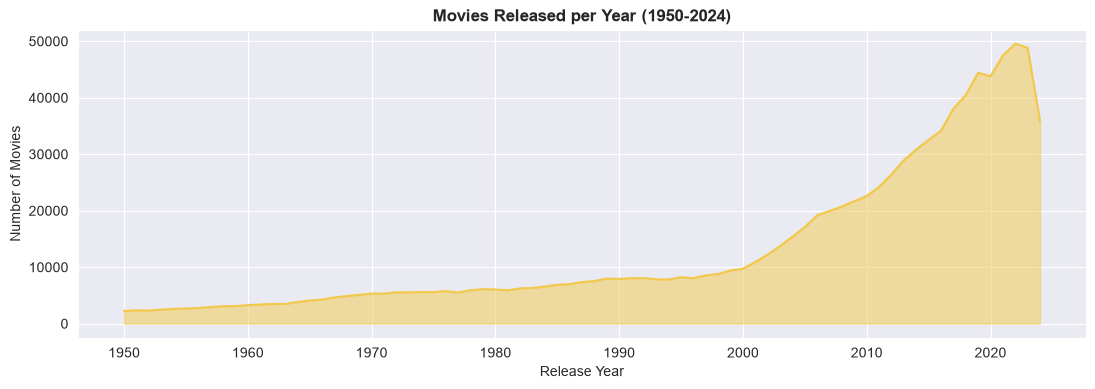

In [57]:
year_counts = (df[df['status'] == 'Released']
               .groupby('release_year').size()
               .reset_index(name='count'))
year_counts = year_counts[
    (year_counts['release_year'] >= 1950) &
    (year_counts['release_year'] <= 2024)
]

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(year_counts['release_year'], year_counts['count'],
                color='#F2C94C', alpha=0.5)
ax.plot(year_counts['release_year'], year_counts['count'],
        color='#F2C94C', linewidth=1.5)
ax.set_title('Movies Released per Year (1950-2024)', fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Movies')
fig.savefig('movies-released-per-year.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** Movie production increased substantially during the 2010s before experiencing a sharp decline in 2020 due to COVID-19 pandemic. Production subsequently recovered, reaching nearly **50,000 released films in 2022**. The dataset captures these changes in production volume but does not establish the factors responsible for the observed increase or decline.

### What Genre Mostly Produced?

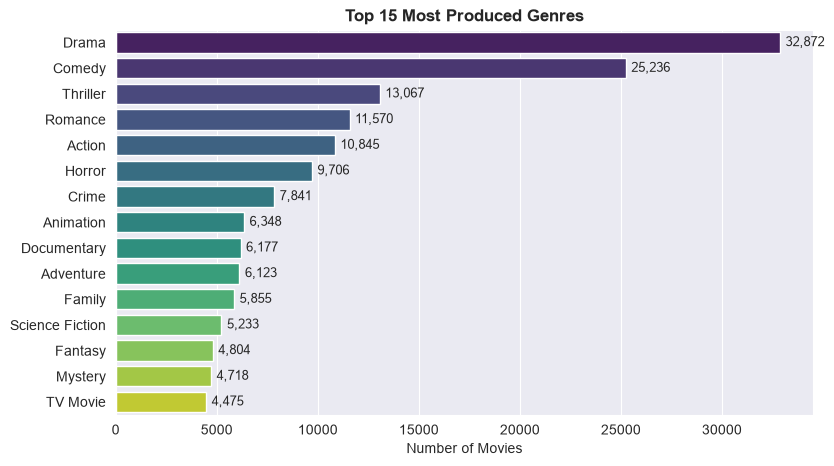

In [58]:
def explode_col(series, sep=","):
    """Split comma-separated string column into a flat and cleaned Series"""
    return (series
            .replace('Not Specified', pd.NA)
            .dropna()
            .str.split(sep)
            .explode()
            .str.strip()
            .replace('', pd.NA)
            .dropna())

genre_series = explode_col(df_rated['genres'])
genre_counts = genre_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=4, fontsize=9)

ax.set_title("Top 15 Most Produced Genres", fontweight='bold')
ax.set_xlabel('Number of Movies')
ax.set_ylabel(None)
fig.savefig('top-15-most-produced-genres.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** Drama is the most-produced genre, with **32,922 films**, followed by Comedy with **25,303 films** and Thriller with **13,074 films**. However, production volume reflects the frequency of films in each genre and does not necessarily indicate higher profitability or lower financial risk.

### Runtime Distribution

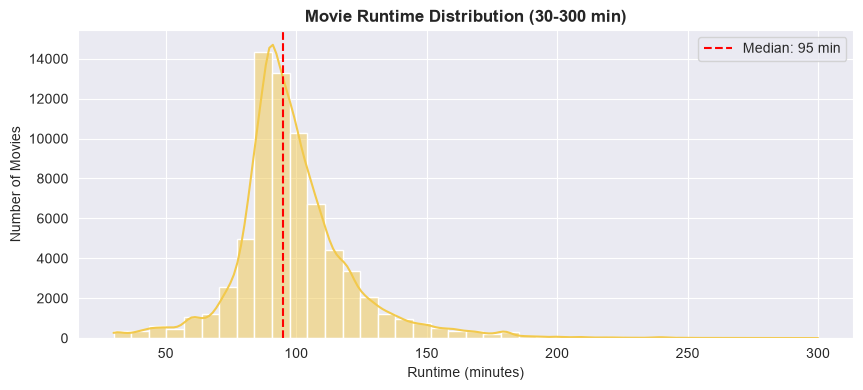

Median runtime : 95 minutes
Mean runtime   : 99 minutes


In [59]:
runtime_clean = df_rated['runtime'].dropna()
runtime_clean = runtime_clean[runtime_clean.between(30, 300)]

fig, ax = plt.subplots(figsize=(10,4))
sns.histplot(runtime_clean, bins=40, kde=True, color='#F2C94C', ax=ax)
ax.axvline(runtime_clean.median(), color='red', linestyle='--', linewidth=1.5, label=f"Median: {runtime_clean.median():.0f} min")
ax.set_title("Movie Runtime Distribution (30-300 min)", fontweight='bold')
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("Number of Movies")
ax.legend()
fig.savefig('movie-runtime-distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Median runtime : {runtime_clean.median():.0f} minutes")
print(f"Mean runtime   : {runtime_clean.mean():.0f} minutes")

**Observation:** Movie runtimes are concentrated around **90–100 minutes**, with a median runtime of **95 minutes**, closely aligned with the standard feature-length format that has defined films since the mid-20th century. Very few films exceed 180 minutes, suggesting that both audience expectations and distribution converge around this range.

### Rating Distribution

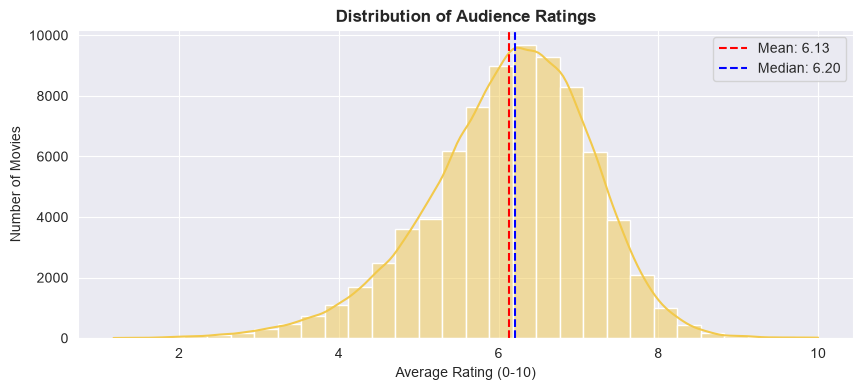

count    78679.00
mean         6.13
std          1.03
min          1.18
25%          5.50
50%          6.20
75%          6.83
max         10.00
Name: vote_average, dtype: float64


In [60]:
mean_rating = df_rated['vote_average'].mean()
median_rating = df_rated['vote_average'].median()

fig, ax = plt.subplots(figsize=(10,4))
sns.histplot(df_rated['vote_average'], bins=30, kde=True, color='#F2C94C', ax=ax)
ax.axvline(mean_rating, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_rating:.2f}")
ax.axvline(median_rating, color='blue', linestyle='--', linewidth=1.5, label=f"Median: {median_rating:.2f}")

ax.set_title("Distribution of Audience Ratings", fontweight="bold")
ax.set_xlabel("Average Rating (0-10)")
ax.set_ylabel("Number of Movies")
ax.legend()
fig.savefig('distribution-of-audience-ratings.png', dpi=300, bbox_inches='tight')
plt.show()

print(df_rated['vote_average'].describe().round(2))

**Observation:** Movie ratings are approximately normally distributed, with the distribution centered around a mean rating of **6.13**. Most films fall within the middle range, while relatively few receive ratings below **3** or above **8**. Ratings above **7.5** are relatively uncommon, indicating stronger-than-typical audience reception within the dataset.

### Language Dominance

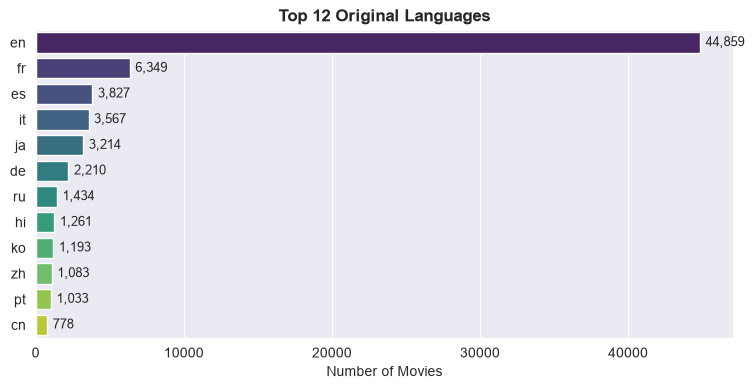

English share of entire dataset: 57.02%


In [61]:
language_counts = df_rated['original_language'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9,4))
sns.barplot(x=language_counts.values, y=language_counts.index, palette='viridis', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=4, fontsize=9)

ax.set_title("Top 12 Original Languages", fontweight='bold')
ax.set_xlabel("Number of Movies")
ax.set_ylabel(None)
fig.savefig('top-12-original-language.png', dpi=300, bbox_inches='tight')
plt.show()

# English language share of the entire filtered dataset
en_pct = df_rated['original_language'].eq('en').mean() * 100
print(f"English share of entire dataset: {en_pct:.2f}%")

**Observation:** English is the dominant original movie language, accounting for **57.05% of the entire filtered dataset**. The remaining films are distributed across multiple other languages, highlighting the dominance of English-language films within the dataset.

### What Percentage of Films Are Actually Profitable?

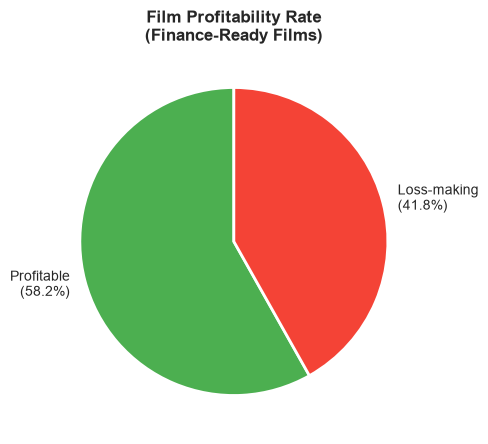

Total films with financial data : 17,254
Profitable (profit > $0)        : 10,036 (58.2%)
Loss-making (profit <= $0)      : 7,218 (41.8%)


In [62]:
profitable = (df_finance['profit'] > 0).sum()
loss_making = (df_finance['profit'] <= 0).sum()
total = df_finance['profit'].notna().sum()
profit_rate = profitable / total * 100

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([profitable, loss_making],
       labels=[f'Profitable\n({profit_rate:.1f}%)',
               f'Loss-making\n({100 - profit_rate:.1f}%)'],
       colors=['#4caf50', '#f44336'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Film Profitability Rate\n(Finance-Ready Films)', fontweight='bold')
fig.savefig('film-profitability-rate.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total films with financial data : {total:,}")
print(f"Profitable (profit > $0)        : {profitable:,} ({profit_rate:.1f}%)")
print(f"Loss-making (profit <= $0)      : {loss_making:,} ({100 - profit_rate:.1f}%)")

**Observation:** Approximately **58.0% of films with complete financial records were profitable**, meaning **roughly 42 in 100 films with known budget and revenue failed to recoup their production cost**. This profitability baseline can be used as reference for the Silver Screen Studios to know how frequently commercial failure occurs even among films substantial enough to have reported financial data.

### Budget vs Revenue: Does More Money In Mean More Money Out?

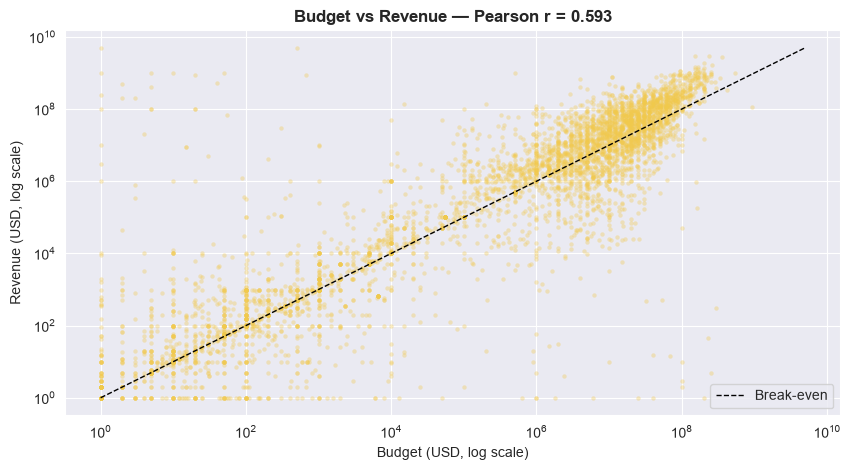

In [63]:
corr = df_finance[['budget', 'revenue']].corr().iloc[0, 1]
sample = df_finance.sample(
    n=min(5000, len(df_finance)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(10,5))
sc = ax.scatter(sample['budget'], sample['revenue'],
                alpha=0.35, color='#F2C94C', s=10, linewidths=0)

ax.set_xscale("log")
ax.set_yscale("log")

min_value = sample[['budget', 'revenue']].min().min()
max_value = sample[['budget', 'revenue']].max().max()

ax.plot([min_value, max_value], [min_value, max_value], "k--", linewidth=1, label="Break-even")

ax.set_title(f"Budget vs Revenue — Pearson r = {corr:.3f}", fontweight='bold')
ax.set_xlabel("Budget (USD, log scale)")
ax.set_ylabel("Revenue (USD, log scale)")
ax.legend()
fig.savefig('budget-vs-revenue.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** Production budget and box-office revenue show a moderate positive correlation (r = 0.590), indicating that higher-budget films tend to generate higher revenue. However, the substantial variation around the relationship suggests that other factors also contribute to commercial performance.

### Runtime vs Rating: Do Longer Films Rate Better?

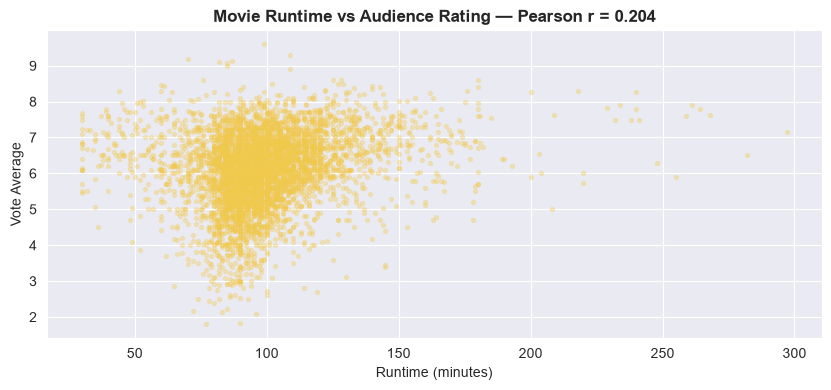

In [64]:
runtime_sample = (df_rated
                  .dropna(subset=['runtime', 'vote_average'])
                  .query("runtime.between(30, 300)")
                  .sample(5000, random_state=42))

corr = runtime_sample[['runtime', 'vote_average']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(10,4))
ax.scatter(runtime_sample['runtime'], runtime_sample['vote_average'],
           alpha=0.3, s=8, color='#F2C94C')
ax.set_title(f"Movie Runtime vs Audience Rating — Pearson r = {corr:.3f}", fontweight='bold')
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("Vote Average")
fig.savefig('movie-runtime-vs-audience-rating.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** Runtime has a weak positive relationship with audience rating (**r = 0.206**), suggesting that longer films tend to receive slightly higher ratings. Ratings appear relatively favorable across the **90–150 minute** range, although the weak correlation indicates that runtime alone has limited association with audience rating.

### Production Volume by Decade

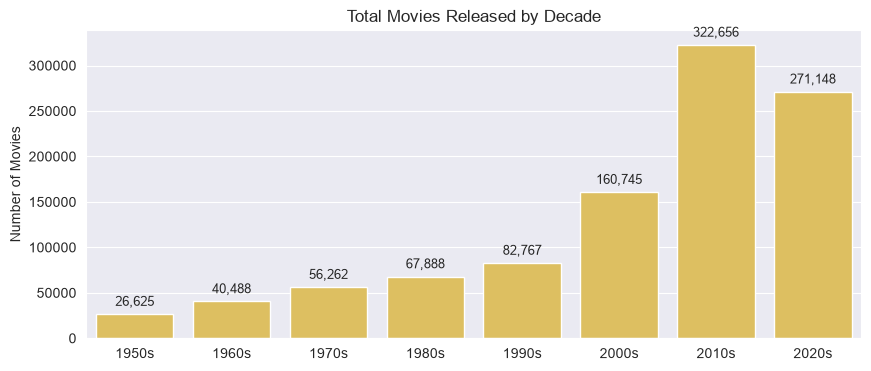

In [65]:
decade_counts = (df[df['status'] == 'Released']
                 .groupby("release_decade").size()
                 .reset_index(name="count")
                 .query("release_decade >= '1950s' and release_decade <= '2020s'"))

fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(data=decade_counts, x='release_decade', y='count',
            color='#F2C94C', edgecolor='white', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=4, fontsize=9)

ax.set_title("Total Movies Released by Decade")
ax.set_xlabel(None)
ax.set_ylabel("Number of Movies")
fig.savefig('total-movies-released-by-decade.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** The 2010s recorded the highest film production volume among the decades analyzed, with **322,662 films**, nearly double the output of the 1990s. This substantial increase indicates significant growth in film production over the period covered by the dataset.

### Which Release Month Generates the Most Revenue?

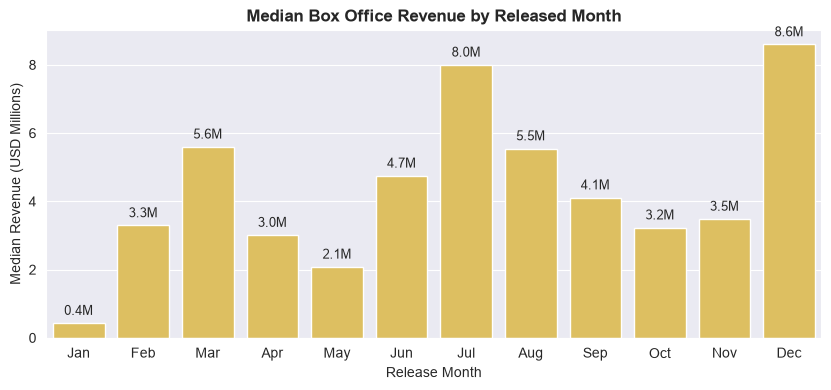

Highest Median Revenue Month: Dec $8.6M (1361 films) 


In [66]:
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
rev_by_month = (df_finance
                .groupby('release_month')['revenue']
                .agg(['median', 'count'])
                .reindex(range(1, 13))
                .reset_index())

rev_by_month['month'] = rev_by_month['release_month'].map(
    dict(enumerate(month_labels, start=1))
)

rev_by_month['median_M'] = rev_by_month['median'] / 1e6

fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(data=rev_by_month, x='month', y='median_M', color='#F2C94C', edgecolor='white', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1fM", padding=4, fontsize=9)

ax.set_title("Median Box Office Revenue by Released Month", fontweight='bold')
ax.set_xlabel("Release Month")
ax.set_ylabel("Median Revenue (USD Millions)")
fig.savefig('median-box-office-revenue-by-released-month.png', dpi=300, bbox_inches='tight')
plt.show()

top_month = rev_by_month.iloc[
    rev_by_month['median'].idxmax()
]

print(
    f"Highest Median Revenue Month: "
    f"{top_month['month']} "
    f"${top_month['median'] / 1e6:.1f}M "
    f"({top_month['count']} films) "
)

**Observation:** March, July, and December record the highest median box-office revenues among the release months, with December ranking first at **\$8.2 million**, followed by July at **\$7.5 million** and March at **\$5.2 million**. This suggests that films released during these months tend to achieve higher typical box-office revenue compared with other release periods.

### Which Genre Earns the Most Revenue?

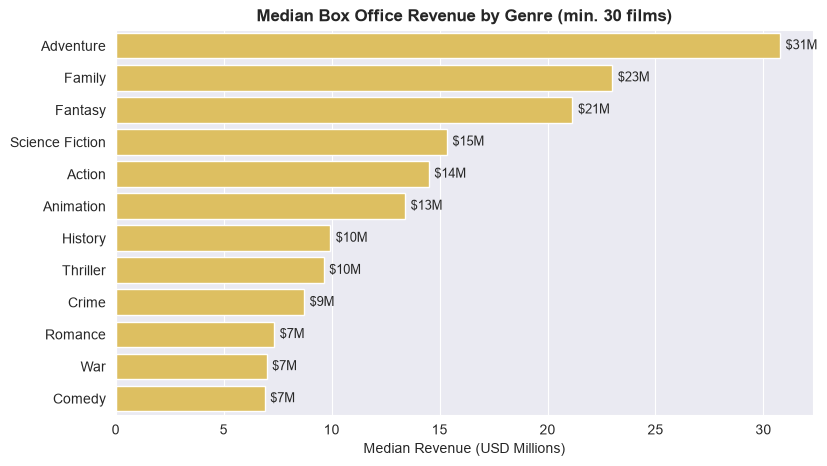

In [67]:
genre_fin = df_finance.copy()

genre_fin = genre_fin[genre_fin['genres'] != 'Not Specified']

genre_fin['genre_split'] = genre_fin['genres'].str.split(',')
genre_fin = genre_fin.explode('genre_split')
genre_fin['genre_split'] = genre_fin['genre_split'].str.strip()

genre_rev = (genre_fin
             .groupby('genre_split')['revenue']
             .agg(['median', 'count'])
             .query('count >= 30')
             .sort_values('median', ascending=False)
             .head(12))

genre_rev["median_M"] = genre_rev["median"] / 1e6

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=genre_rev.reset_index(),
            x='median_M',
            y='genre_split',
            color='#F2C94C',
            ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0fM", padding=4, fontsize=9)

ax.set_title("Median Box Office Revenue by Genre (min. 30 films)", fontweight='bold')
ax.set_xlabel('Median Revenue (USD Millions)')
ax.set_ylabel(None)
fig.savefig('median-box-office-revenue-by-genre.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** Adventure records the highest median box-office revenue among genres with at least 30 films, indicating stronger typical financial performance within the dataset. However, the result represents the median performance of each genre and does not imply that every film within the genre achieves similar revenue.

## Which Genre Is Rated Highest?

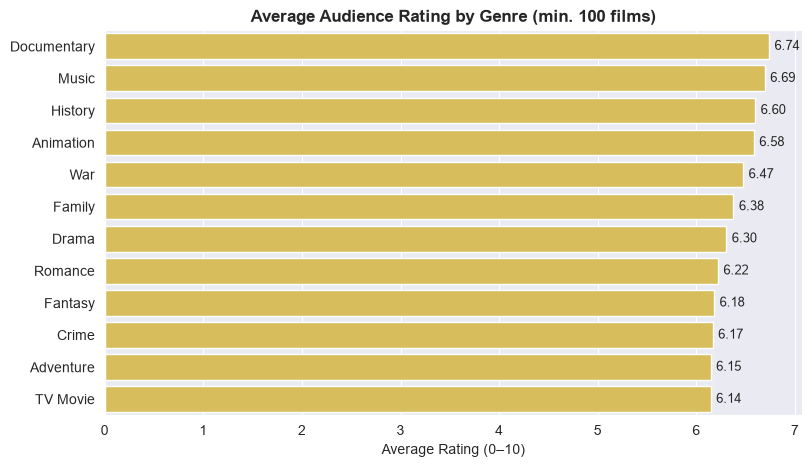

In [68]:
genre_rated = df_rated[df_rated['genres'] != 'Not Specified'].copy()
genre_rated['genre_split'] = genre_rated['genres'].str.split(',')
genre_rated = genre_rated.explode('genre_split')
genre_rated['genre_split'] = genre_rated['genre_split'].str.strip()

genre_vote = (genre_rated
              .groupby('genre_split')['vote_average']
              .agg(['mean', 'count'])
              .query('count >= 100')
              .sort_values('mean', ascending=False)
              .head(12))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=genre_vote.reset_index(),
            x='mean', y='genre_split',
            color='#EDC948', ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=4, fontsize=9)

ax.set_title("Average Audience Rating by Genre (min. 100 films)", fontweight='bold')
ax.set_xlabel("Average Rating (0–10)")
ax.set_ylabel(None)
fig.savefig('average-audience-rating-by-genre.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** Documentary and Music genres receive the highest average audience ratings with **6.74 for Documentary** and **6.69 for Music**. This reflects strong reception from the audiences that engage with these films. This distinction is directly relevant to Silver Screen Studios when deciding whether a project is for financial returns, awards consideration, or both.

### Top-Grossing Films (Leaderboard)

In [69]:
# Restrict the dataset to films with positive budget, positive revenue, a non-zero audience rating, and a plausible release year.
df_finance_valid = df_finance[
    (df_finance["budget"] > 0) &
    (df_finance["revenue"] > 0) &
    (df_finance["vote_average"] > 0) &
    (df_finance["release_year"].between(1950, 2024))
].copy()

top10 = (df_finance_valid
         .nlargest(10, "revenue")
         [["title", "release_year", "genres", "budget",
           "revenue", "profit", "roi", "vote_average"]]
         .reset_index(drop=True))
top10.index += 1

top10["budget"] = top10["budget"].apply(lambda x: f"${x/1e6:.0f}M" if pd.notna(x) else "N/A")
top10["revenue"] = top10["revenue"].apply(lambda x: f"${x/1e6:.0f}M" if pd.notna(x) else "N/A")
top10["profit"] = top10["profit"].apply(lambda x: f"${x/1e6:.0f}M" if pd.notna(x) else "N/A")
top10["roi"] = top10["roi"].apply(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A")
top10["vote_average"] = top10["vote_average"].round(1)

top10.columns = ["Title", "Year", "Genre", "Budget", "Revenue", "Profit", "ROI", "Rating"]

print("Top 10 Highest-Grossing Films")
display(top10)

Top 10 Highest-Grossing Films


,Title,Year,Genre,Budget,Revenue,Profit,ROI,Rating
1,TikTok Rizz Party,2024,"Drama, Comedy",$250M,$3000M,$2750M,1100.0%,10.0
2,Avatar,2009,"Action, Adventure, Fantasy, Science Fiction",$237M,$2924M,$2687M,1133.6%,7.6
3,Avengers: Endgame,2019,"Adventure, Science Fiction, Action",$356M,$2800M,$2444M,686.5%,8.3
4,Avatar: The Way of Water,2022,"Science Fiction, Adventure, Action",$460M,$2320M,$1860M,404.4%,7.7
5,Titanic,1997,"Drama, Romance",$200M,$2264M,$2064M,1032.1%,7.9
6,Star Wars: The Force Awakens,2015,"Adventure, Action, Science Fiction",$245M,$2068M,$1823M,744.2%,7.3
7,Avengers: Infinity War,2018,"Adventure, Action, Science Fiction",$300M,$2052M,$1752M,584.1%,8.3
8,Spider-Man: No Way Home,2021,"Action, Adventure, Science Fiction",$200M,$1922M,$1722M,860.9%,8.0
9,Jurassic World,2015,"Action, Adventure, Science Fiction, Thriller",$150M,$1672M,$1522M,1014.4%,6.7
10,The Lion King,2019,"Adventure, Drama, Family",$260M,$1663M,$1403M,539.6%,7.1


**Observation:** The top 10 highest-grossing films are dominated by franchise entries like sequels and adaptations, concentrated in the Action, Adventure, and Science Fiction genres. While these films generated exceptional revenue and profit, their ROI values vary, demonstrating that box-office scale and investment efficiency are distinct measures of financial success. Silver Screen Studios should note that most films on the list benefit from franchise momentum and major studio distribution, structural advantages that provide important context when interpreting these results.

## Key Findings & Insights

### Production Trends

- Film production grew consistently from the 1950s through the 2010s, with the 2010s recording the highest decade output at over 322,000 released films, reflecting the global expansion of the film industry and the rise of digital filmmaking.
- A sharp decline occurred in 2020, consistent with the disruption caused by the COVID-19 pandemic, before recovering to nearly 50,000 released films in 2022.
- Release timing shows meaningful variation in financial performance: **December (\$8.2M), July (\$7.5M), and March (\$5.2M)** produced the highest median box-office revenues, suggesting these windows carry an advantage for wide theatrical releases.

### Financial Performance

- Production budget and box-office revenue are moderately correlated **(r = 0.590)**, confirming that higher investment tends to produce higher revenue, but the wide variance across films with similar budgets confirms that budget alone does not determine commercial outcomes.
- Only **58% of films with complete financial records were profitable**, meaning **42 in 100 films** failed to recoup their production costs. This baseline rate of commercial failure is a critical reference point for Silver Screen Studios' project evaluation process.
- The highest-grossing films are concentrated in franchise-driven Action, Adventure, and Science Fiction productions. High absolute revenue does not consistently correspond to high ROI, as investment efficiency varies significantly even among the top earners.

### Audience Reception & Genre Performance

- Audience ratings follow a near-normal distribution centered at a mean of **6.13**. A rating above **7.5** represents the upper tier of audience reception in this dataset, which is a meaningful benchmark for Silver Screen Studios when setting creative quality targets.
- Runtime has only a weak positive relationship with audience ratings **(r = 0.206), indicating that film length is not a reliable driver of stronger audience reception.
- Drama is the most produced genre at **32,922 films** but does not lead on median revenue, demonstrating that production volume and commercial performance are distinct dimensions.
- **Adventure leads on median box-office revenue**, while **Documentary and Music lead on average audience ratings**, confirming a consistent gap between financial and critical performance across genres. Genres strong on both dimensions represent the most strategically balanced choices for the studio.

## Business Implications

1. **Prioritize December and July release windows for major productions.** Both months consistently deliver the highest median box-office revenue in the dataset, with **\$8.2M** and **\$7.5M** respectively. For Silver Screen Studios, scheduling high-budget productions around these windows reduces the timing-related revenue risk.
2. **Treat production budget as necessary but not sufficient.** The moderate correlation between budget and revenue (r = 0.590) confirms that investment level matters. However, the wide dispersion in outcomes means that increasing the budget does not guarantee proportional financial returns. Genre selection, release timing, and creative execution each contribute independently.
3. **Align genre selection to project goals.** Adventure and Family genres carry the strongest historical revenue track records. Documentary and Music genres carry the strongest audience rating track records. Silver Screen Studios should define its primary success criterion per project such as financial return, critical reception, or both before committing to a genre, since optimizing for one does not reliably produce the other.
4. **Apply a realistic profitability benchmark to every greenlight decision.** With only 58% of financially-reported films achieving profitability, Silver Screen Studios should treat commercial success as probable rather than certain and build project approval frameworks that explicitly account for the realistic likelihood of loss before production begins.

## Limitations

- **Financial data coverage** - Budget and revenue records are only available for a small fraction of the full dataset. Findings reflect films large enough to have reported box-office figures, which biases results toward major studio productions. Smaller and independent films are underrepresented.
- **No inflation adjustment** - Revenue and budget figures are nominal values. Comparing financial figures across decades overstates the revenue of recent films relative to older productions and should be interpreted with caution.
- **Platform-specific ratings** - Audience ratings reflect TMDb users, a self-selected online audience. They may not represent the general moviegoing public or critical consensus.
- **Correlation does not imply causation** - Relationships identified in this analysis describe historical associations within the dataset and do not establish causal mechanisms.
- **Metadata completeness** - The dataset may contain incomplete, synthetic, or inconsistent metadata that affects certain analyses, particularly for older or less prominent productions.
- **Subset scope** - Financial analyses are restricted to released films with both budget and revenue reported. Audience analyses are restricted to released films with at least 10 votes. Findings do not generalize to the full 1.4M-record dataset.

## Conclusion

This exploratory analysis examined historical movie data from the TMDb dataset to address the core business problem facing Silver Screen Studios: understanding which factors are most consistently associated with commercial and critical success in film production.

The findings show that production budget carries a moderate positive relationship with box-office revenue, but the wide variation in financial outcomes across films with similar budgets confirms that investment level alone cannot guarantee returns. Release timing and genre both show meaningful differences in typical performance, December and July emerge as the strongest revenue windows, while Adventure and Animation lead commercially. The profitability analysis reveals that roughly 42 in 100 films with reported financial data failed to recover their production costs, establishing a baseline risk rate that Silver Screen Studios should incorporate into its project evaluation process.

For Silver Screen Studios, the most actionable output of this analysis is a clearer evidential foundation for investment decisions: which release windows carry a revenue advantage, which genres align with financial versus critical objectives, and what the realistic probability of commercial failure looks like at the industry level. These findings do not predict the outcome of any individual film, but they provide the historical context that separates data-informed decisions from intuition-based ones. Further work, such as revenue prediction modeling and franchise versus original IP analysis would extend these findings into more precise decision-support tools for the studio's investment committee.